# Fraud Detection — Data Exploration

Exploratory analysis of the IEEE-CIS fraud detection dataset.

| File | Description |
|---|---|
| `train_transaction.csv` | Transaction records with the target `isFraud` |
| `train_identity.csv` | Device/identity attributes for a subset of transactions |

In [128]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from bisect import bisect_left

pd.set_option("display.max_columns", 50)
pd.set_option("display.float_format", "{:.4f}".format)

DATA_DIR = "../data"

## Load Data

In [129]:
trn = pd.read_csv(f"{DATA_DIR}/train_transaction.csv")
idn = pd.read_csv(f"{DATA_DIR}/train_identity.csv")

print(f"train_transaction : {trn.shape[0]:,} rows × {trn.shape[1]} cols")
print(f"train_identity    : {idn.shape[0]:,} rows × {idn.shape[1]} cols")

# Left join — only 24% of transactions have identity data
merged = trn.merge(idn, on="TransactionID", how="left")
print(f"\nMerged            : {merged.shape[0]:,} rows × {merged.shape[1]} cols")
print(f"Identity coverage : {idn['TransactionID'].nunique() / len(trn):.1%}")

train_transaction : 590,540 rows × 394 cols
train_identity    : 144,233 rows × 41 cols

Merged            : 590,540 rows × 434 cols
Identity coverage : 24.4%


In [130]:
trn.head(3)

,TransactionID,isFraud,TransactionDT,TransactionAmt,ProductCD,card1,card2,card3,card4,card5,card6,addr1,addr2,dist1,dist2,P_emaildomain,R_emaildomain,C1,C2,C3,C4,C5,C6,C7,C8,...,V315,V316,V317,V318,V319,V320,V321,V322,V323,V324,V325,V326,V327,V328,V329,V330,V331,V332,V333,V334,V335,V336,V337,V338,V339
0,2987000,0,86400,68.5000,W,13926,NaN,150.0000,discover,142.0000,credit,315.0000,87.0000,19.0000,NaN,NaN,NaN,1.0000,1.0000,0.0000,0.0000,0.0000,1.0000,0.0000,0.0000,...,0.0000,0.0000,117.0000,0.0000,0.0000,0.0000,0.0000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2987001,0,86401,29.0000,W,2755,404.0000,150.0000,mastercard,102.0000,credit,325.0000,87.0000,NaN,NaN,gmail.com,NaN,1.0000,1.0000,0.0000,0.0000,0.0000,1.0000,0.0000,0.0000,...,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2987002,0,86469,59.0000,W,4663,490.0000,150.0000,visa,166.0000,debit,330.0000,87.0000,287.0000,NaN,outlook.com,NaN,1.0000,1.0000,0.0000,0.0000,0.0000,1.0000,0.0000,0.0000,...,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [131]:
idn.head(3)

,TransactionID,id_01,id_02,id_03,id_04,id_05,id_06,id_07,id_08,id_09,id_10,id_11,id_12,id_13,id_14,id_15,id_16,id_17,id_18,id_19,id_20,id_21,id_22,id_23,id_24,id_25,id_26,id_27,id_28,id_29,id_30,id_31,id_32,id_33,id_34,id_35,id_36,id_37,id_38,DeviceType,DeviceInfo
0,2987004,0.0000,70787.0000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,100.0000,NotFound,NaN,-480.0000,New,NotFound,166.0000,NaN,542.0000,144.0000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,New,NotFound,Android 7.0,samsung browser 6.2,32.0000,2220x1080,match_status:2,T,F,T,T,mobile,SAMSUNG SM-G892A Build/NRD90M
1,2987008,-5.0000,98945.0000,NaN,NaN,0.0000,-5.0000,NaN,NaN,NaN,NaN,100.0000,NotFound,49.0000,-300.0000,New,NotFound,166.0000,NaN,621.0000,500.0000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,New,NotFound,iOS 11.1.2,mobile safari 11.0,32.0000,1334x750,match_status:1,T,F,F,T,mobile,iOS Device
2,2987010,-5.0000,191631.0000,0.0000,0.0000,0.0000,0.0000,NaN,NaN,0.0000,0.0000,100.0000,NotFound,52.0000,NaN,Found,Found,121.0000,NaN,410.0000,142.0000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Found,Found,NaN,chrome 62.0,NaN,NaN,NaN,F,F,T,T,desktop,Windows


---
## Key Findings

Five core questions answered about the dataset.

### Q1. How many rows and columns in each file? What's the join key?

In [132]:
print(f"train_transaction : {trn.shape[0]:,} rows × {trn.shape[1]} cols")
print(f"train_identity    : {idn.shape[0]:,} rows × {idn.shape[1]} cols")
print(f"\nJoin key : TransactionID")
print(f"Identity rows present in transactions : {idn['TransactionID'].isin(trn['TransactionID']).all()}")
print(f"Transactions with identity data       : {idn['TransactionID'].nunique():,} / {len(trn):,} ({idn['TransactionID'].nunique()/len(trn):.1%})")

train_transaction : 590,540 rows × 394 cols
train_identity    : 144,233 rows × 41 cols

Join key : TransactionID
Identity rows present in transactions : True
Transactions with identity data       : 144,233 / 590,540 (24.4%)


### Q2. What's the fraud rate?

Not fraud : 569,877
Fraud     : 20,663
Fraud rate: 3.50%  (~1 in 28 transactions)


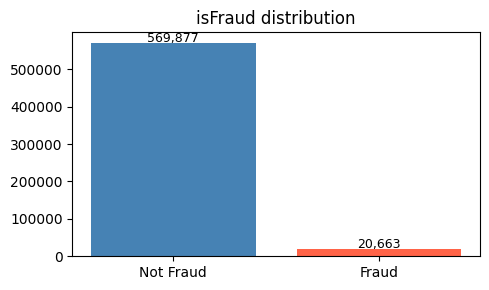

In [133]:
vc = trn["isFraud"].value_counts()
fraud_rate = vc[1] / len(trn)

print(f"Not fraud : {vc[0]:,}")
print(f"Fraud     : {vc[1]:,}")
print(f"Fraud rate: {fraud_rate:.2%}  (~1 in {int(1/fraud_rate)} transactions)")

fig, ax = plt.subplots(figsize=(5, 3))
ax.bar(["Not Fraud", "Fraud"], vc.values, color=["steelblue", "tomato"])
ax.set_title("isFraud distribution")
for i, v in enumerate(vc.values):
    ax.text(i, v + 2000, f"{v:,}", ha="center", fontsize=9)
plt.tight_layout()
plt.show()

### Q3. How many columns have missing values, and how severe?


train_transaction  (394 total cols)
  Cols with any missing : 374
  > 75% missing         : 168
  25 – 75% missing      : 44
  < 25% missing         : 162

train_identity  (41 total cols)
  Cols with any missing : 38
  > 75% missing         : 9
  25 – 75% missing      : 10
  < 25% missing         : 19


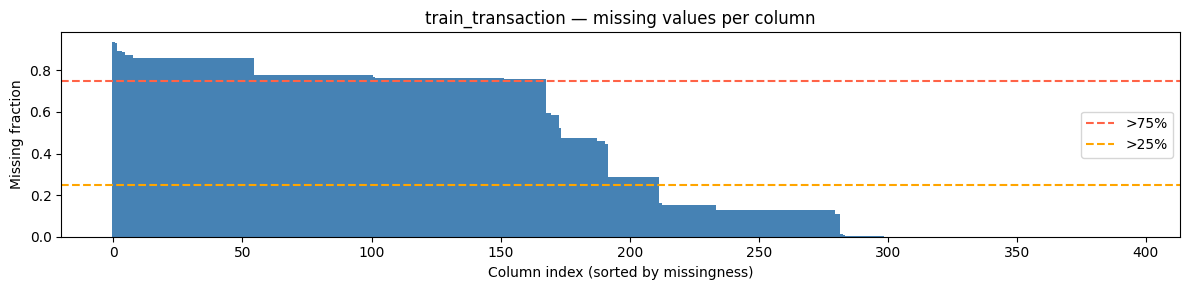

In [134]:
def missing_summary(df, name):
    miss = df.isnull().mean() * 100
    print(f"\n{name}  ({df.shape[1]} total cols)")
    print(f"  Cols with any missing : {(miss > 0).sum()}")
    print(f"  > 75% missing         : {(miss > 75).sum()}")
    print(f"  25 – 75% missing      : {((miss > 25) & (miss <= 75)).sum()}")
    print(f"  < 25% missing         : {((miss > 0) & (miss <= 25)).sum()}")

missing_summary(trn, "train_transaction")
missing_summary(idn, "train_identity")

# Visualise missing rate across all trn columns
miss_trn = trn.isnull().mean().sort_values(ascending=False)
fig, ax = plt.subplots(figsize=(12, 3))
ax.bar(range(len(miss_trn)), miss_trn.values, color="steelblue", width=1)
ax.axhline(0.75, color="tomato", linestyle="--", label=">75%")
ax.axhline(0.25, color="orange", linestyle="--", label=">25%")
ax.set_xlabel("Column index (sorted by missingness)")
ax.set_ylabel("Missing fraction")
ax.set_title("train_transaction — missing values per column")
ax.legend()
plt.tight_layout()
plt.show()

### Q4. What does TransactionAmt look like — distribution, range, outliers?

Min    : $0.25
Median : $68.77
Mean   : $135.03
Max    : $31937.39
Std    : $239.16
Skew   : 14.37  (heavily right-skewed)
99th % : $1104.00
IQR outliers: 66,482 (11.3%)


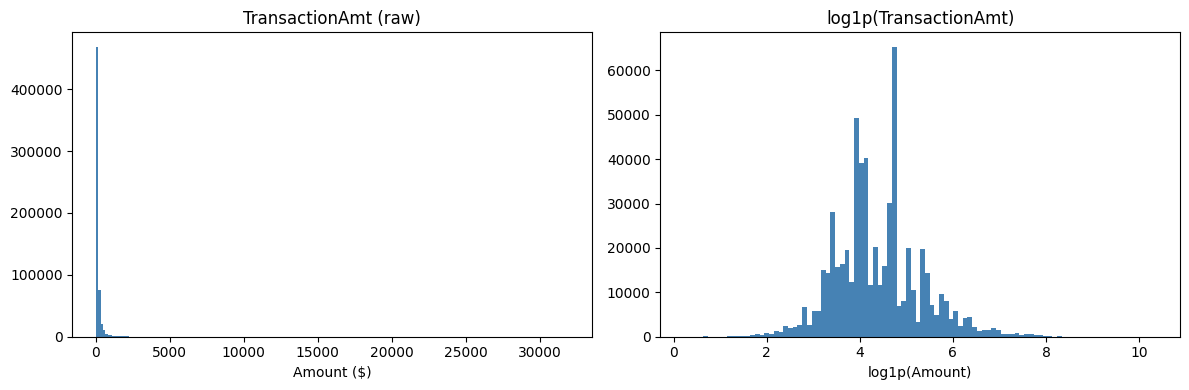

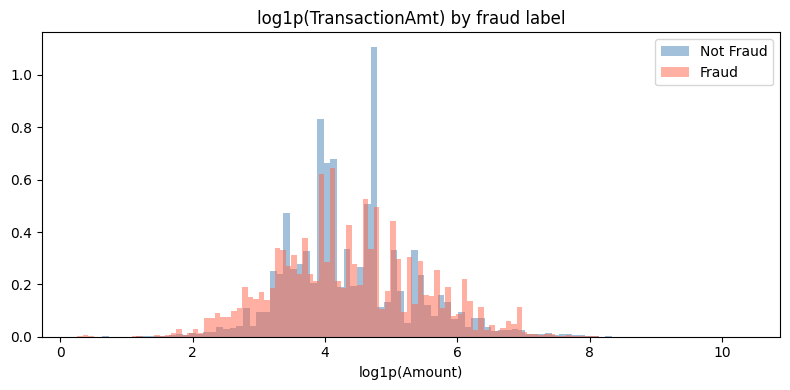

In [135]:
amt = trn["TransactionAmt"]
q25, q75 = amt.quantile(0.25), amt.quantile(0.75)
iqr = q75 - q25
n_outliers = ((amt < q25 - 1.5 * iqr) | (amt > q75 + 1.5 * iqr)).sum()

print(f"Min    : ${amt.min():.2f}")
print(f"Median : ${amt.median():.2f}")
print(f"Mean   : ${amt.mean():.2f}")
print(f"Max    : ${amt.max():.2f}")
print(f"Std    : ${amt.std():.2f}")
print(f"Skew   : {amt.skew():.2f}  (heavily right-skewed)")
print(f"99th % : ${amt.quantile(0.99):.2f}")
print(f"IQR outliers: {n_outliers:,} ({n_outliers/len(amt):.1%})")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(amt, bins=200, color="steelblue", edgecolor="none")
axes[0].set_title("TransactionAmt (raw)")
axes[0].set_xlabel("Amount ($)")

axes[1].hist(np.log1p(amt), bins=100, color="steelblue", edgecolor="none")
axes[1].set_title("log1p(TransactionAmt)")
axes[1].set_xlabel("log1p(Amount)")

plt.tight_layout()
plt.show()

# Fraud vs non-fraud amount
fig, ax = plt.subplots(figsize=(8, 4))
for label, color in [(0, "steelblue"), (1, "tomato")]:
    subset = np.log1p(trn.loc[trn["isFraud"] == label, "TransactionAmt"])
    ax.hist(subset, bins=100, alpha=0.5, color=color, label=["Not Fraud", "Fraud"][label], density=True)
ax.set_title("log1p(TransactionAmt) by fraud label")
ax.set_xlabel("log1p(Amount)")
ax.legend()
plt.tight_layout()
plt.show()

### Q5. What are the ProductCD and card columns?

ProductCD  (W=web, C=cash, R=refund, H=hotel?, S=services?)
            count  fraud_rate  share
ProductCD                           
C           68519      0.1169 0.1160
S           11628      0.0590 0.0197
H           33024      0.0477 0.0559
R           37699      0.0378 0.0638
W          439670      0.0204 0.7445


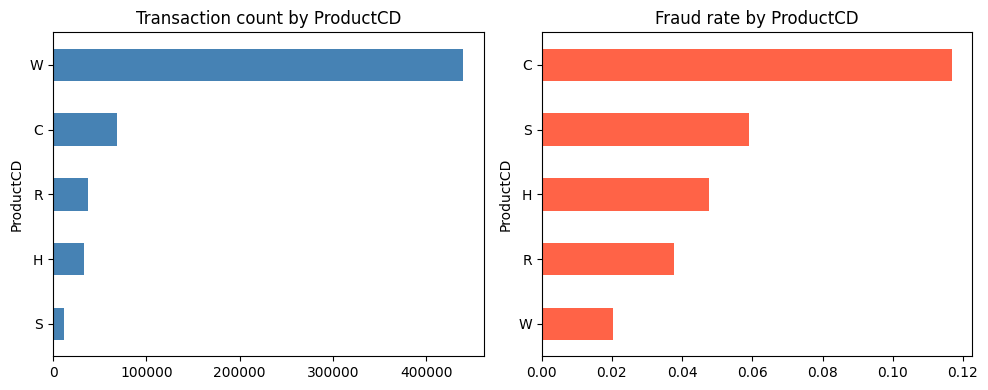

In [136]:
# ProductCD — product category
prod = trn.groupby("ProductCD").agg(
    count=("isFraud", "count"),
    fraud_rate=("isFraud", "mean")
).sort_values("fraud_rate", ascending=False)
prod["share"] = prod["count"] / len(trn)
print("ProductCD  (W=web, C=cash, R=refund, H=hotel?, S=services?)")
print(prod.to_string())

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
prod["count"].sort_values().plot(kind="barh", ax=axes[0], title="Transaction count by ProductCD", color="steelblue")
prod["fraud_rate"].sort_values().plot(kind="barh", ax=axes[1], title="Fraud rate by ProductCD", color="tomato")
plt.tight_layout()
plt.show()

card1: Card identifier (anonymized numeric)
card2: Card attribute (anonymized numeric, 500 unique values)
card3: Card attribute (anonymized numeric, 114 unique values)
card4: Card network  — visa / mastercard / amex / discover
card5: Card attribute (anonymized numeric, 119 unique values)
card6: Card type     — debit / credit


Fraud rate by card4:
                 fraud_rate   count
card4                              
visa                  3.48%  384767
mastercard            3.43%  189217
american express      2.87%    8328
discover              7.73%    6651

Fraud rate by card6:
                fraud_rate   count
card6                             
debit                2.43%  439938
credit               6.68%  148986
debit or credit      0.00%      30
charge card          0.00%      15


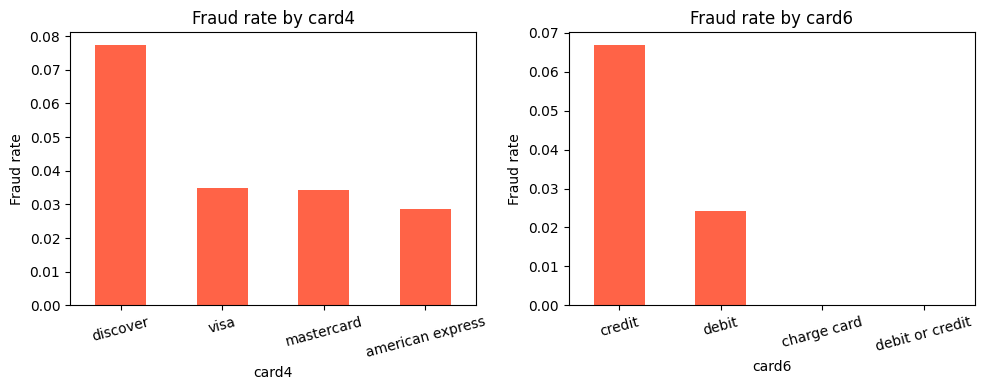

In [137]:
# Card columns overview
card_meta = {
    "card1": "Card identifier (anonymized numeric)",
    "card2": "Card attribute (anonymized numeric, 500 unique values)",
    "card3": "Card attribute (anonymized numeric, 114 unique values)",
    "card4": "Card network  — visa / mastercard / amex / discover",
    "card5": "Card attribute (anonymized numeric, 119 unique values)",
    "card6": "Card type     — debit / credit",
}
for col, desc in card_meta.items():
    print(f"{col}: {desc}")

print()

# card4 and card6 fraud rates (interpretable columns)
for col in ["card4", "card6"]:
    print(f"\nFraud rate by {col}:")
    summary = trn.groupby(col)["isFraud"].agg(["mean", "count"]).rename(columns={"mean": "fraud_rate"})
    summary["fraud_rate"] = summary["fraud_rate"].apply(lambda x: f"{x:.2%}")
    print(summary.sort_values("count", ascending=False).to_string())

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
for ax, col in zip(axes, ["card4", "card6"]):
    rates = trn.groupby(col)["isFraud"].mean().sort_values(ascending=False)
    rates.plot(kind="bar", ax=ax, title=f"Fraud rate by {col}", color="tomato", rot=15)
    ax.set_ylabel("Fraud rate")
plt.tight_layout()
plt.show()

---
## Feature Engineering

Hand-crafted features that capture behavioural signals useful for fraud detection.

### Velocity — transactions per card in the last hour

A high transaction count in a short window is a strong fraud signal.  
Uses binary search (`bisect_left`) for O(log n) per row instead of a linear scan.

In [142]:
def make_card_addr(df):
    """Composite key: card number + billing address identifies a unique cardholder."""
    return df["card1"].astype(str) + "-" + df["addr1"].astype(str)


def compute_velocity(df):
    """
    Add `velocity_1h`: number of prior transactions by the same cardholder
    within the 60 minutes before each transaction.

    Parameters
    ----------
    df : pd.DataFrame  Must contain card1, addr1, TransactionDT.

    Returns
    -------
    pd.DataFrame  Input with `card_addr` and `velocity_1h` columns added.
    """
    df = df.copy()
    df["card_addr"] = make_card_addr(df)
    df = df.sort_values(["card_addr", "TransactionDT"])

    counts = []
    for _, group in df.groupby("card_addr"):
        times = group["TransactionDT"].tolist()
        # bisect_left finds the insertion point in O(log n):
        #   right = index of current txn (excluded via bisect_left)
        #   left  = index of first txn within the 1-hour window
        counts.extend(
            bisect_left(times, t) - bisect_left(times, t - 3600)
            for t in times
        )

    df["velocity_1h"] = counts
    return df

In [143]:
sample = trn.head(10_000).copy()
sample = compute_velocity(sample)

print(sample[["TransactionID", "card_addr", "TransactionDT", "velocity_1h"]].head(10))
print(f"\nMax velocity_1h : {sample['velocity_1h'].max()}")
print(f"Mean velocity_1h: {sample['velocity_1h'].mean():.2f}")

      TransactionID    card_addr  TransactionDT  velocity_1h
1962        2988962  10004-220.0         141079            0
1945        2988945  10004-315.0         140871            0
8960        2995960  10023-204.0         261338            0
7258        2994258  10023-264.0         236956            0
7376        2994376  10023-264.0         238218            1
158         2987158  10023-325.0          88997            0
236         2987236  10023-325.0          90149            1
279         2987279  10023-325.0          90808            2
714         2987714  10023-325.0         100169            0
1049        2988049  10023-325.0         114875            0

Max velocity_1h : 11
Mean velocity_1h: 0.51


### Amount Deviation — how unusual is this transaction's amount?

Measures how far a transaction deviates from that cardholder's historical mean.  
Only past transactions are used (no data leakage via `shift(1)`).

In [140]:
def compute_amount_deviation(df):
    """
    Add `hist_mean_amt` and `amt_deviation` for each transaction.

    `hist_mean_amt` is the average of all *prior* transactions by the same
    cardholder. `amt_deviation` is how much the current transaction differs
    from that baseline — positive means spent more than usual.

    Parameters
    ----------
    df : pd.DataFrame  Must contain card1, addr1, TransactionDT, TransactionAmt.

    Returns
    -------
    pd.DataFrame  Input sorted by cardholder + time, with two new columns:
                  - hist_mean_amt : historical mean (NaN filled with current amt
                                    for a cardholder's first transaction)
                  - amt_deviation : TransactionAmt - hist_mean_amt (0 for first)
    """
    # Avoid mutating the caller's dataframe
    df = df.copy()

    # Composite key: card number + billing address identifies a unique cardholder
    df["card_addr"] = make_card_addr(df)

    # Sort so expanding window sees transactions in chronological order
    df_sorted = df.sort_values(["card_addr", "TransactionDT"])

    # Historical mean: average of all *prior* transactions for this cardholder.
    # shift(1) excludes the current row so we only use past data (no leakage).
    df_sorted["hist_mean_amt"] = (
        df_sorted.groupby("card_addr")["TransactionAmt"]
        .transform(lambda x: x.expanding().mean().shift(1))
    )

    # Positive = spent more than usual, negative = spent less than usual
    df_sorted["amt_deviation"] = df_sorted["TransactionAmt"] - df_sorted["hist_mean_amt"]

    # First transaction per cardholder has no history — treat deviation as 0
    df_sorted["amt_deviation"] = df_sorted["amt_deviation"].fillna(0)
    # First transaction per cardholder has no history — use current amt as baseline
    df_sorted["hist_mean_amt"] = df_sorted["hist_mean_amt"].fillna(df_sorted["TransactionAmt"])

    return df_sorted

In [141]:
amt_dev = compute_amount_deviation(sample)

print(amt_dev[["TransactionID", "card_addr", "TransactionAmt", "hist_mean_amt", "amt_deviation"]].head(10))
print(f"\nMax deviation : ${amt_dev['amt_deviation'].max():.2f}")
print(f"Min deviation : ${amt_dev['amt_deviation'].min():.2f}")

      TransactionID    card_addr  TransactionAmt  hist_mean_amt  amt_deviation
1962        2988962  10004-220.0         72.9500        72.9500         0.0000
1945        2988945  10004-315.0         72.9500        72.9500         0.0000
8960        2995960  10023-204.0         12.9700        12.9700         0.0000
7258        2994258  10023-264.0         10.0000        10.0000         0.0000
7376        2994376  10023-264.0         44.0000        10.0000        34.0000
158         2987158  10023-325.0        171.0000       171.0000         0.0000
236         2987236  10023-325.0         30.0000       171.0000      -141.0000
279         2987279  10023-325.0         59.0000       100.5000       -41.5000
714         2987714  10023-325.0         59.0000        86.6667       -27.6667
1049        2988049  10023-325.0         87.9500        79.7500         8.2000

Max deviation : $3166.41
Min deviation : $-3137.95
